    area  perimeter majoraxislength  minoraxislength  aspectration  \
0  28395    610.291      208.178117       173.888747      1.197191   
1  28734    638.018      200.524796       182.734419      1.097356   
2  29380    624.110       212.82613       175.931143      1.209713   
3  30008    645.884      210.557999       182.516516      1.153638   
4  30140    620.134      201.847882       190.279279      1.060798   

   eccentricity  convexarea  equivdiameter    extent  solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   compactness  shapefactor1  shapefactor2  shapefactor3  shapefactor4  class  
0     0.913358      0.007332      0.

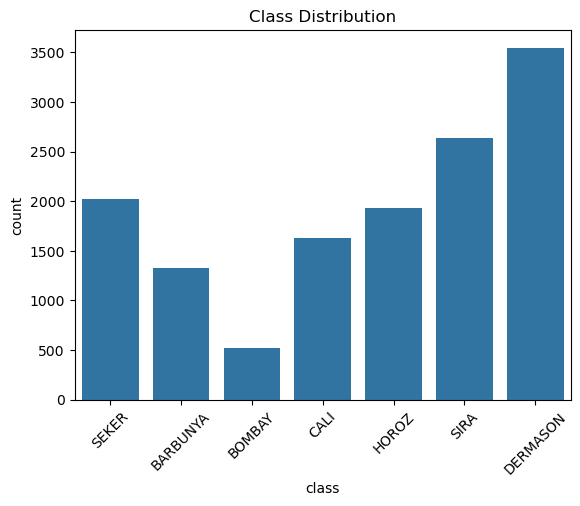

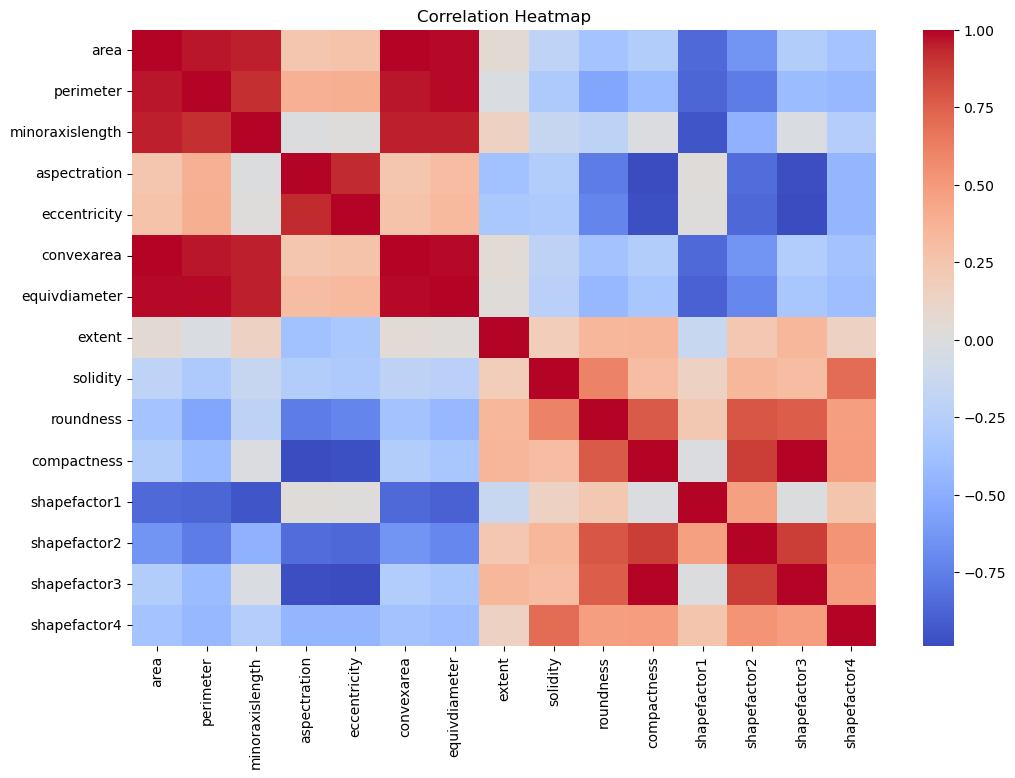

area               0
perimeter          0
majoraxislength    0
minoraxislength    0
aspectration       0
eccentricity       0
convexarea         0
equivdiameter      0
extent             0
solidity           0
roundness          0
compactness        0
shapefactor1       0
shapefactor2       0
shapefactor3       0
shapefactor4       0
class              0
dtype: int64


ValueError: could not convert string to float: ''

In [ ]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

import pickle
import warnings
warnings.filterwarnings("ignore")

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_excel("beans_data.xlsx")

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w_]", "", regex=True)
    .str.replace(r"_+", "_", regex=True)
)


# 1. Clean column names
df.columns = df.columns.str.strip()

# 2. Trim all string values
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 3. Replace ALL blank values with NaN
df.replace(['', ' '], np.nan, inplace=True)

# 4. Clean target column
df["Class"] = df["Class"].str.strip()

# 5. Separate features & target
X = df.drop("Class", axis=1)
y = df["Class"]

# 6. Convert features to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# 7. Fill missing values
X.fillna(X.median(), inplace=True)
print(df.head())
print(df.info())
print(df.describe())

# ===============================
# 3. EDA
# ===============================

# Class distribution
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Pairplot (optional, heavy)
# sns.pairplot(df, hue='Class')
# plt.show()

# ===============================
# 4. MISSING VALUES
# ===============================
print(df.isnull().sum())

# ===============================
# 5. OUTLIER TREATMENT (IQR)
# ===============================
def remove_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df = remove_outliers(df)

# ===============================
# 6. SPLIT DATA
# ===============================
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===============================
# 7. SCALING
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 8. HANDLE IMBALANCE (SMOTE)
# ===============================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# ===============================
# 9. MODEL TRAINING
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred, average='weighted')

    overfit = "Yes" if train_acc - test_acc > 0.05 else "No"

    results.append([name, train_acc, test_acc, f1, overfit])

    print(f"\n{name}")
    print(classification_report(y_test, y_test_pred))

# ===============================
# 10. RESULTS TABLE
# ===============================
results_df = pd.DataFrame(results, columns=[
    "Model", "Train Accuracy", "Test Accuracy", "F1 Score", "Overfitting"
])

print(results_df.sort_values(by="F1 Score", ascending=False))

# ===============================
# 11. HYPERPARAMETER TUNING (RF)
# ===============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

# Evaluate best model
y_pred = best_model.predict(X_test)

print("\nFinal Model Performance")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test, y_pred))

# ===============================
# 12. SAVE MODEL & SCALER
# ===============================
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model saved successfully!")

In [ ]:
df.head(1)

,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
23,31637,656.711,229.719255,175.510446,1.308864,0.645191,32045,200.702465,0.761823,0.987268,0.921842,0.873686,0.007261,0.00261,0.763327,0.999091,SEKER
